In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
PROJECT_ROOT = Path("../../").resolve()

DATA_DIR = PROJECT_ROOT / "data" / "raw" / "biomarkers" / "framingham"
ARTIFACT_DIR = PROJECT_ROOT / "artifacts" / "eda" / "framingham"

ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

print("Data directory:", DATA_DIR)
print("Exists:", DATA_DIR.exists())
print("Artifact directory:", ARTIFACT_DIR)

Data directory: D:\Programming\VS Code\Projects\CardioFusion-XAI\ml-service\data\raw\biomarkers\framingham
Exists: True
Artifact directory: D:\Programming\VS Code\Projects\CardioFusion-XAI\ml-service\artifacts\eda\framingham


In [3]:
csv_files = list(DATA_DIR.glob("*.csv"))

print("CSV files found:", len(csv_files))

for path in csv_files:
    print(path.name)

CSV files found: 1
framingham.csv


In [4]:
if not csv_files:
    raise FileNotFoundError(f"No CSV files found in {DATA_DIR}")

DATA_PATH = csv_files[0]

df = pd.read_csv(DATA_PATH)

print("Loaded:", DATA_PATH.name)
print("Shape:", df.shape)

Loaded: framingham.csv
Shape: (4240, 16)


In [5]:
print("Columns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
display(df.head())

Columns:
['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose', 'TenYearCHD']

First 5 rows:


,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [6]:
print("Data types:")
print(df.dtypes)

print("\nSummary statistics:")
display(df.describe(include="all").T)

Data types:
male                 int64
age                  int64
education          float64
currentSmoker        int64
cigsPerDay         float64
BPMeds             float64
prevalentStroke      int64
prevalentHyp         int64
diabetes             int64
totChol            float64
sysBP              float64
diaBP              float64
BMI                float64
heartRate          float64
glucose            float64
TenYearCHD           int64
dtype: object

Summary statistics:


,count,mean,std,min,25%,50%,75%,max
male,4240.0,0.429245,0.495027,0.00,0.00,0.0,1.00,1.0
age,4240.0,49.580189,8.572942,32.00,42.00,49.0,56.00,70.0
education,4135.0,1.979444,1.019791,1.00,1.00,2.0,3.00,4.0
currentSmoker,4240.0,0.494104,0.500024,0.00,0.00,0.0,1.00,1.0
cigsPerDay,4211.0,9.005937,11.922462,0.00,0.00,0.0,20.00,70.0
BPMeds,4187.0,0.029615,0.169544,0.00,0.00,0.0,0.00,1.0
prevalentStroke,4240.0,0.005896,0.076569,0.00,0.00,0.0,0.00,1.0
prevalentHyp,4240.0,0.310613,0.462799,0.00,0.00,0.0,1.00,1.0
diabetes,4240.0,0.025708,0.158280,0.00,0.00,0.0,0.00,1.0
totChol,4190.0,236.699523,44.591284,107.00,206.00,234.0,263.00,696.0


In [8]:
missing = pd.DataFrame({
    "missing_count": df.isna().sum(),
    "missing_percent": df.isna().mean() * 100
})

missing = missing.sort_values("missing_percent", ascending=False)

display(missing)

,missing_count,missing_percent
glucose,388,9.150943
education,105,2.476415
BPMeds,53,1.250000
totChol,50,1.179245
cigsPerDay,29,0.683962
BMI,19,0.448113
heartRate,1,0.023585
male,0,0.000000
prevalentHyp,0,0.000000
prevalentStroke,0,0.000000


In [9]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


TenYearCHD
0    3596
1     644
Name: count, dtype: int64


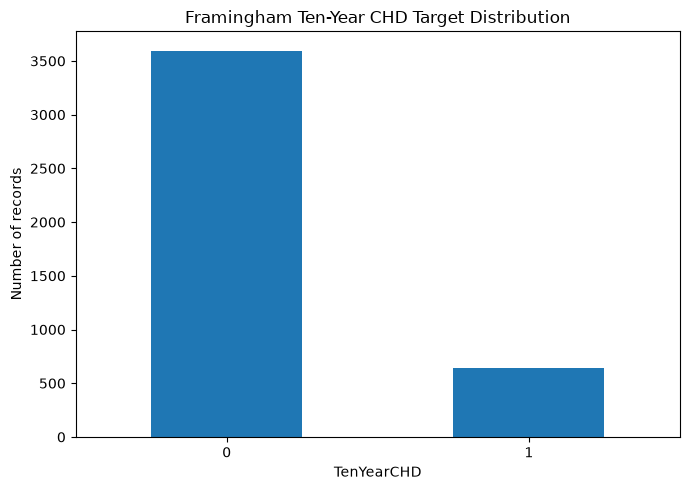

In [10]:
TARGET = "TenYearCHD"

if TARGET not in df.columns:
    raise KeyError(
        f"{TARGET!r} not found. Available columns:\n{df.columns.tolist()}"
    )

print(df[TARGET].value_counts(dropna=False))

plt.figure(figsize=(7, 5))
df[TARGET].value_counts().sort_index().plot(kind="bar")
plt.xlabel("TenYearCHD")
plt.ylabel("Number of records")
plt.title("Framingham Ten-Year CHD Target Distribution")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [11]:
target_counts = df[TARGET].value_counts()

target_percent = (
    target_counts / len(df) * 100
).round(2)

print("Target counts:")
print(target_counts)

print("\nTarget percentages:")
print(target_percent)

Target counts:
TenYearCHD
0    3596
1     644
Name: count, dtype: int64

Target percentages:
TenYearCHD
0    84.81
1    15.19
Name: count, dtype: float64


Numeric features:
['male', 'age', 'education', 'currentSmoker', 'cigsPerDay', 'BPMeds', 'prevalentStroke', 'prevalentHyp', 'diabetes', 'totChol', 'sysBP', 'diaBP', 'BMI', 'heartRate', 'glucose']


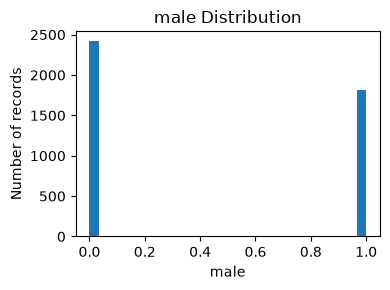

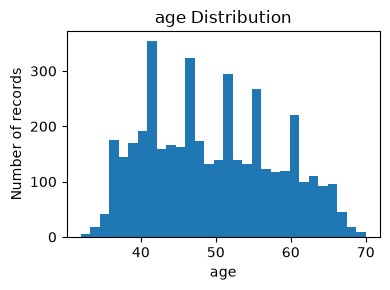

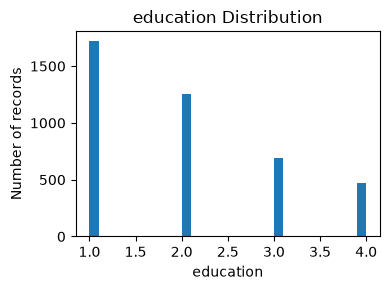

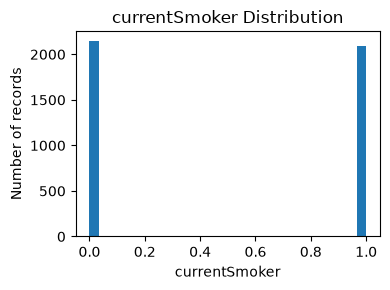

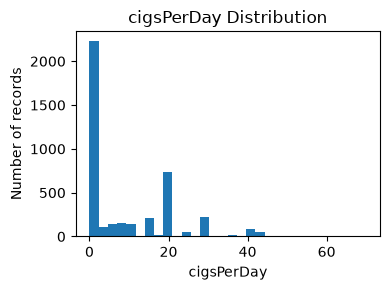

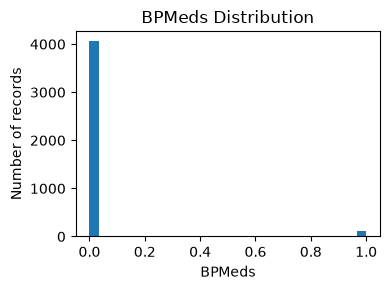

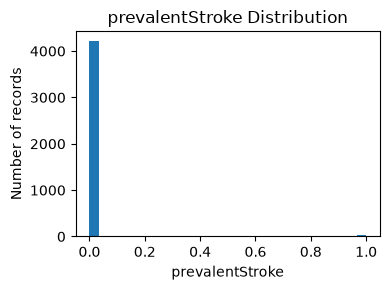

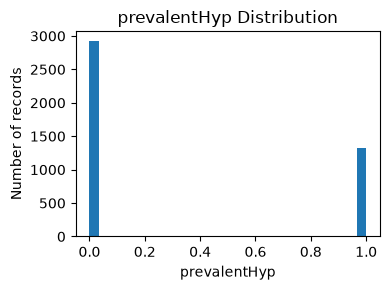

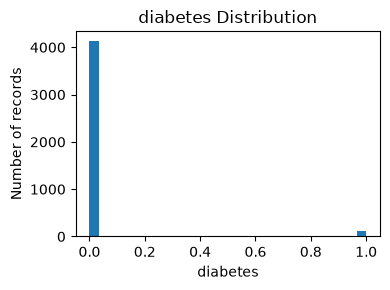

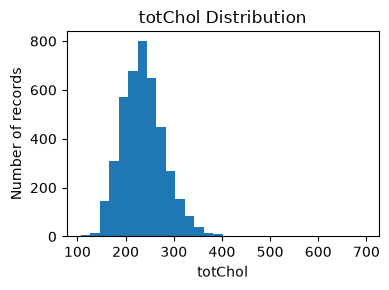

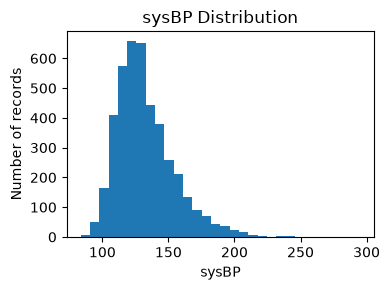

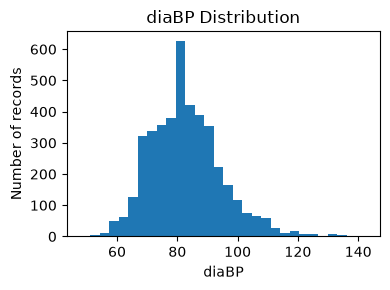

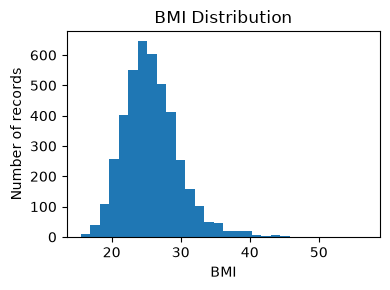

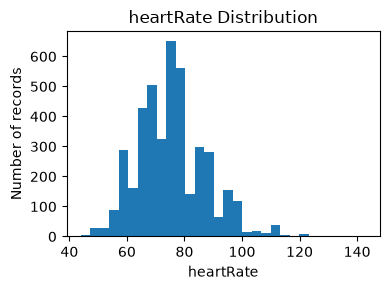

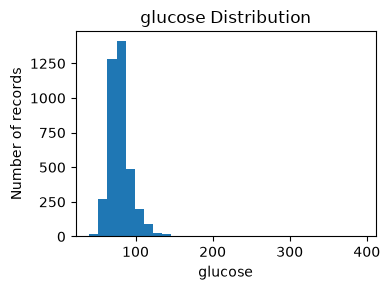

In [13]:
numeric_columns = df.select_dtypes(include=np.number).columns.tolist()

if TARGET in numeric_columns:
    numeric_columns.remove(TARGET)

print("Numeric features:")
print(numeric_columns)

for col in numeric_columns:
    plt.figure(figsize=(4, 3))
    plt.hist(df[col].dropna(), bins=30)
    plt.xlabel(col)
    plt.ylabel("Number of records")
    plt.title(f"{col} Distribution")
    plt.tight_layout()
    plt.show()

In [14]:
correlations = (
    df[numeric_columns + [TARGET]]
    .corr(numeric_only=True)[TARGET]
    .drop(TARGET)
    .sort_values(key=lambda x: x.abs(), ascending=False)
)

display(correlations.to_frame("correlation_with_TenYearCHD"))

,correlation_with_TenYearCHD
age,0.225408
sysBP,0.216374
prevalentHyp,0.177458
diaBP,0.145112
glucose,0.125590
diabetes,0.097344
male,0.088374
BPMeds,0.087519
totChol,0.082369
BMI,0.075300


<Figure size 300x200 with 0 Axes>

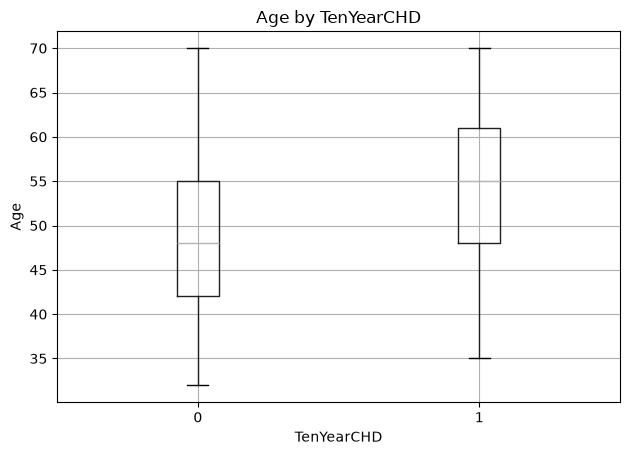

In [17]:
if "age" in df.columns:
    plt.figure(figsize=(3, 2))
    df.boxplot(column="age", by=TARGET)
    plt.xlabel("TenYearCHD")
    plt.ylabel("Age")
    plt.title("Age by TenYearCHD")
    plt.suptitle("")
    plt.tight_layout()
    plt.show()

<Figure size 300x200 with 0 Axes>

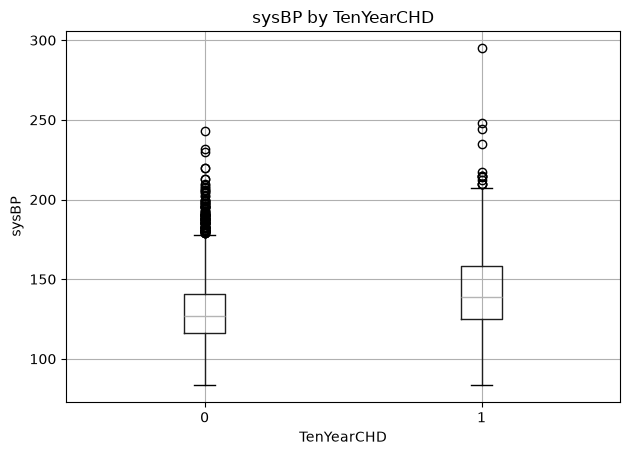

<Figure size 300x200 with 0 Axes>

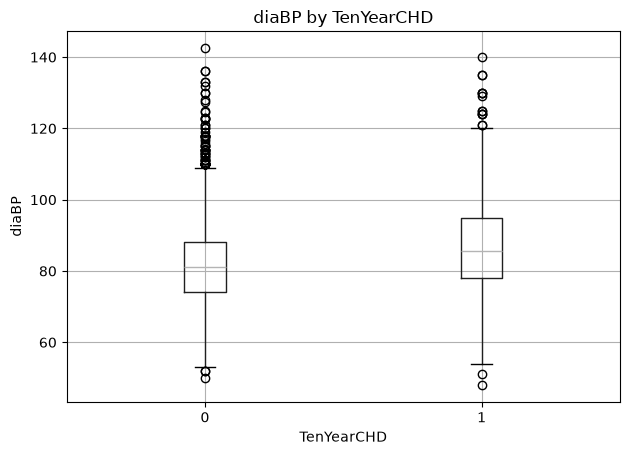

In [19]:
bp_columns = [c for c in ["sysBP", "diaBP"] if c in df.columns]

for col in bp_columns:
    plt.figure(figsize=(3, 2))
    df.boxplot(column=col, by=TARGET)
    plt.xlabel("TenYearCHD")
    plt.ylabel(col)
    plt.title(f"{col} by TenYearCHD")
    plt.suptitle("")
    plt.tight_layout()
    plt.show()

<Figure size 300x200 with 0 Axes>

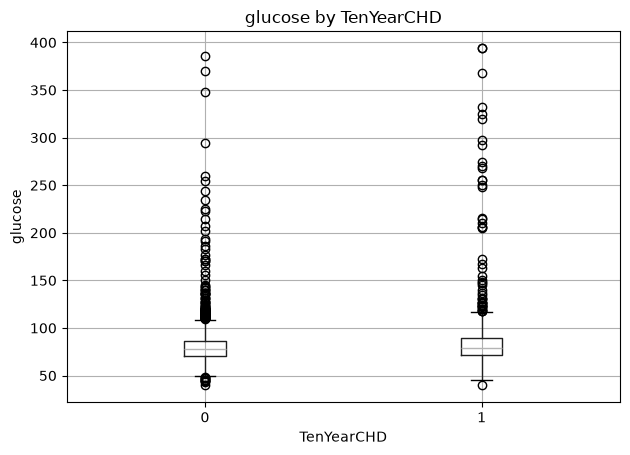

<Figure size 300x200 with 0 Axes>

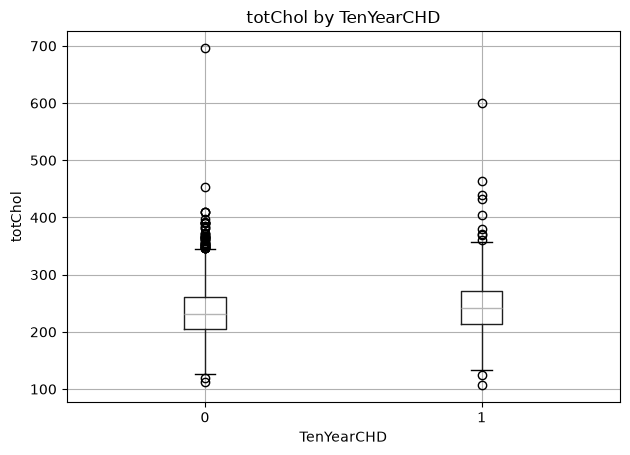

<Figure size 300x200 with 0 Axes>

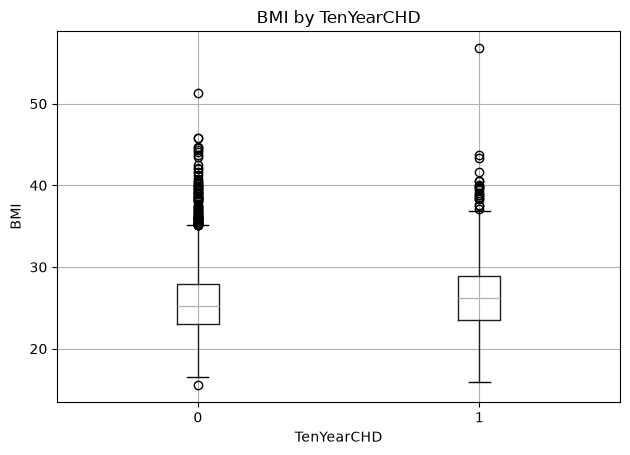

In [21]:
for col in ["glucose", "totChol", "BMI"]:
    if col in df.columns:
        plt.figure(figsize=(3, 2))
        df.boxplot(column=col, by=TARGET)
        plt.xlabel("TenYearCHD")
        plt.ylabel(col)
        plt.title(f"{col} by TenYearCHD")
        plt.suptitle("")
        plt.tight_layout()
        plt.show()

In [22]:
outlier_summary = []

for col in numeric_columns:
    values = df[col].dropna()

    q1 = values.quantile(0.25)
    q3 = values.quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    count = ((values < lower) | (values > upper)).sum()

    outlier_summary.append({
        "feature": col,
        "outlier_count": int(count),
        "outlier_percent": round(count / len(values) * 100, 2)
    })

outlier_df = pd.DataFrame(outlier_summary)
display(outlier_df.sort_values("outlier_percent", ascending=False))

,feature,outlier_count,outlier_percent
14,glucose,188,4.88
10,sysBP,126,2.97
5,BPMeds,124,2.96
8,diabetes,109,2.57
12,BMI,97,2.30
11,diaBP,77,1.82
13,heartRate,76,1.79
9,totChol,56,1.34
6,prevalentStroke,25,0.59
4,cigsPerDay,12,0.28


In [23]:
print("Unique TenYearCHD values:")
print(sorted(df[TARGET].dropna().unique()))

invalid_target = ~df[TARGET].isin([0, 1])

print("Invalid target rows:", invalid_target.sum())

Unique TenYearCHD values:
[np.int64(0), np.int64(1)]
Invalid target rows: 0


In [24]:
range_check = pd.DataFrame({
    "min": df[numeric_columns].min(),
    "max": df[numeric_columns].max(),
    "mean": df[numeric_columns].mean(),
    "median": df[numeric_columns].median()
})

display(range_check)

,min,max,mean,median
male,0.00,1.0,0.429245,0.0
age,32.00,70.0,49.580189,49.0
education,1.00,4.0,1.979444,2.0
currentSmoker,0.00,1.0,0.494104,0.0
cigsPerDay,0.00,70.0,9.005937,0.0
BPMeds,0.00,1.0,0.029615,0.0
prevalentStroke,0.00,1.0,0.005896,0.0
prevalentHyp,0.00,1.0,0.310613,0.0
diabetes,0.00,1.0,0.025708,0.0
totChol,107.00,696.0,236.699523,234.0


In [25]:
summary = {
    "dataset": "Framingham Heart Study",
    "rows": len(df),
    "columns": len(df.columns),
    "duplicates": int(df.duplicated().sum()),
    "target": TARGET,
    "positive_cases": int((df[TARGET] == 1).sum()),
    "negative_cases": int((df[TARGET] == 0).sum()),
    "positive_percent": round((df[TARGET] == 1).mean() * 100, 2),
    "negative_percent": round((df[TARGET] == 0).mean() * 100, 2),
}

summary_df = pd.DataFrame([summary])

display(summary_df)

summary_df.to_csv(
    ARTIFACT_DIR / "framingham_eda_summary.csv",
    index=False
)

print("Saved:", ARTIFACT_DIR / "framingham_eda_summary.csv")

,dataset,rows,columns,duplicates,target,positive_cases,negative_cases,positive_percent,negative_percent
0,Framingham Heart Study,4240,16,0,TenYearCHD,644,3596,15.19,84.81


Saved: D:\Programming\VS Code\Projects\CardioFusion-XAI\ml-service\artifacts\eda\framingham\framingham_eda_summary.csv
